In [2]:
! pip install rich

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [rich]


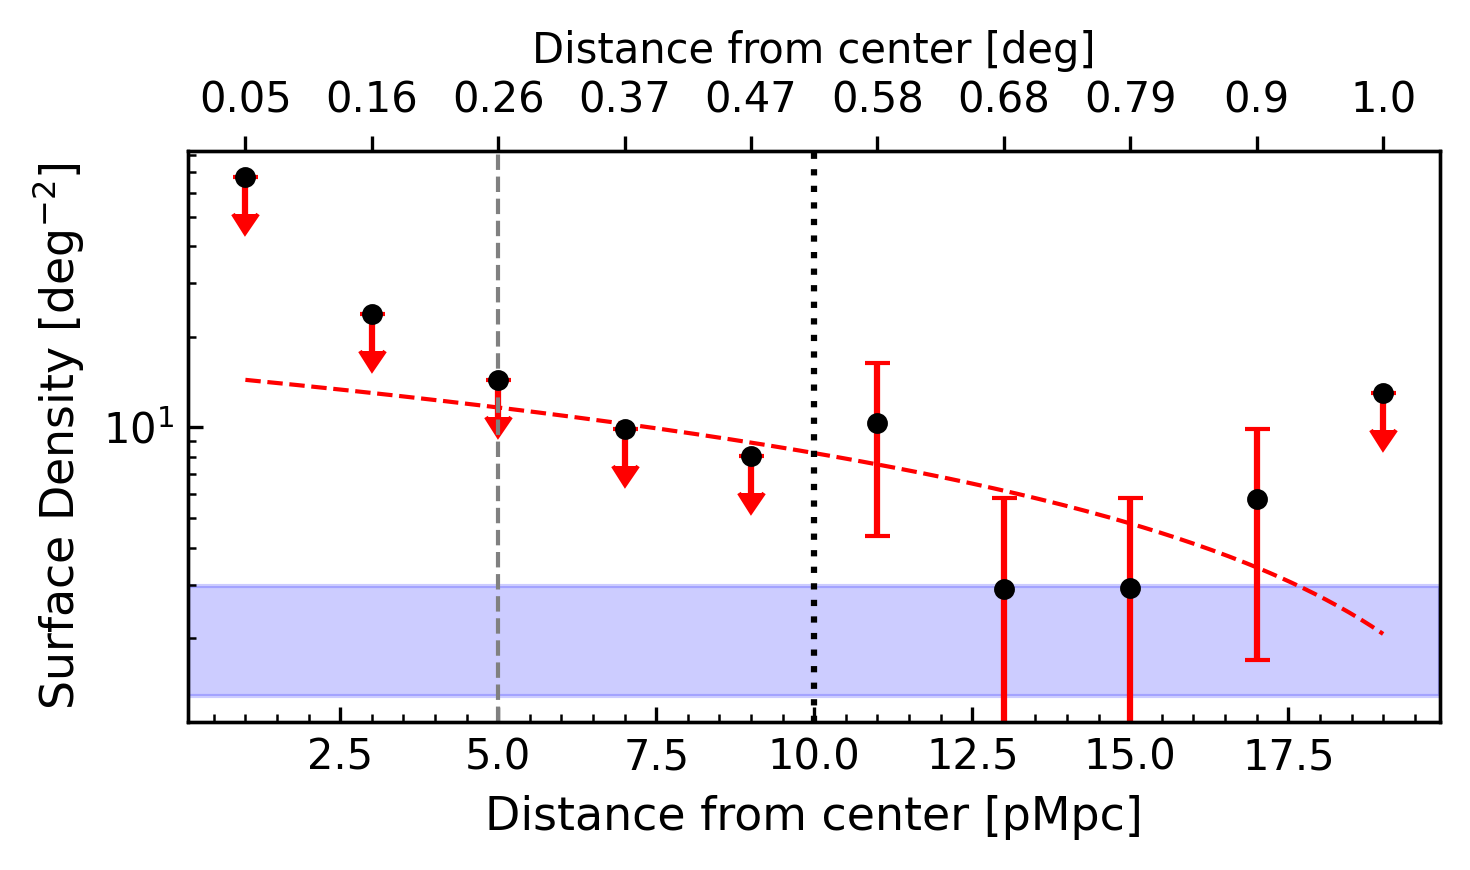

Saved: plots/cdfs_profile.png


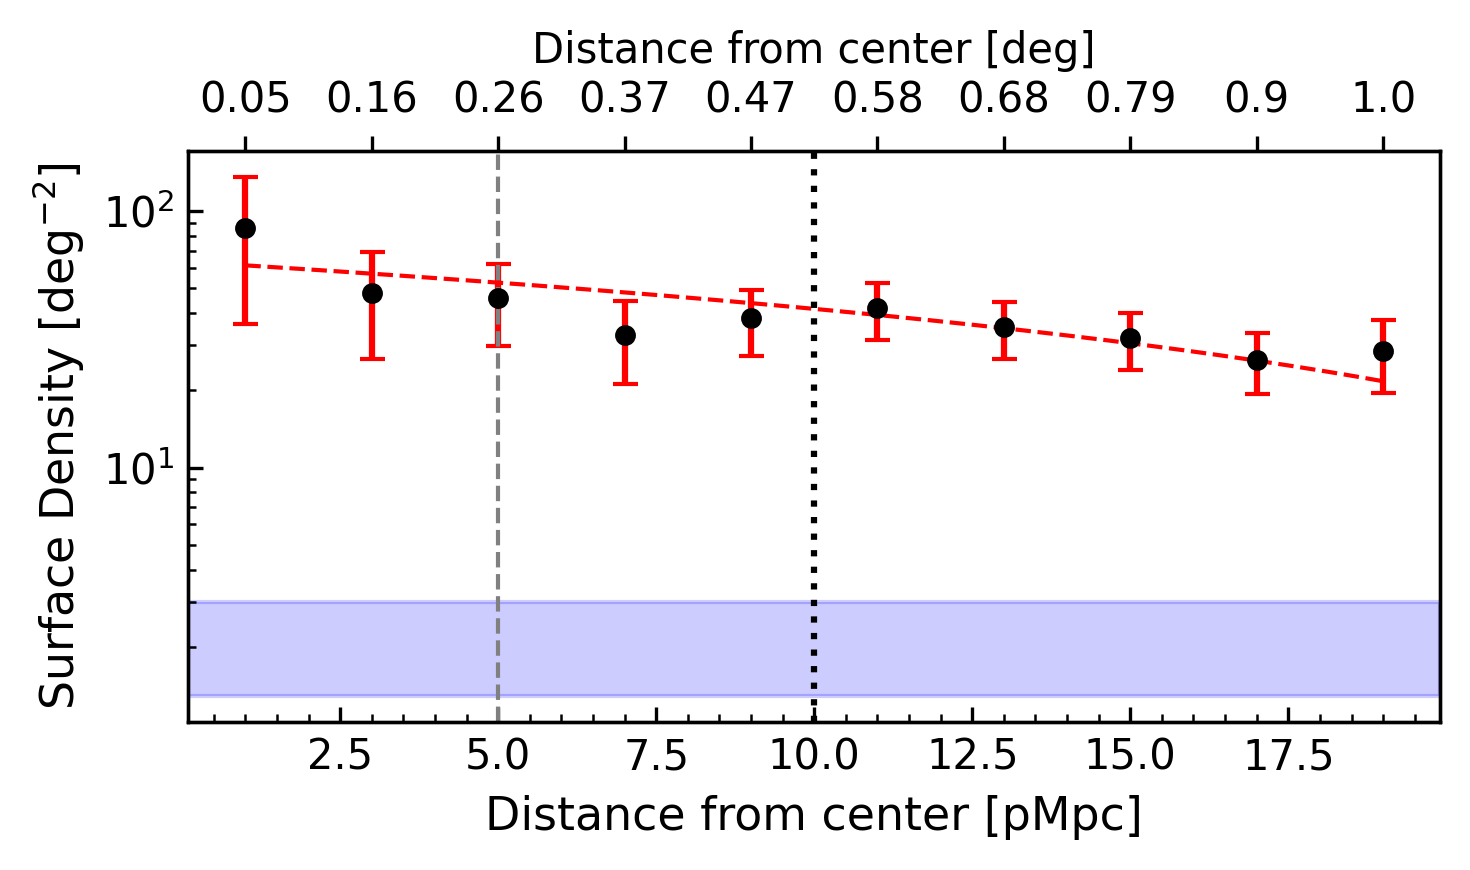

Saved: plots/decam_profile.png


In [ ]:
"""
Radial surface density (final corrected + publication-quality)
"""

import numpy as np
from astropy.io import fits
from astropy.wcs import WCS
from astropy.wcs.utils import proj_plane_pixel_scales
import astropy.units as u
from astropy.cosmology import FlatLambdaCDM
from astropy.coordinates import SkyCoord
import matplotlib.pyplot as plt
from scipy.stats import linregress
import os


# ----------------------------
# QSO + COSMOLOGY
# ----------------------------
RA_QSO = (23 + (48/60) + (33.34/3600)) * (360/24)
DEC_QSO = (30 + (54/60) + (10.0/3600)) * -1
REDSHIFT_QSO = 6.9

COSMO = FlatLambdaCDM(H0=70, Om0=0.3)
ARCSEC_PER_KPC = COSMO.arcsec_per_kpc_proper(REDSHIFT_QSO)
ARCSEC_PER_KPC_CO = COSMO.arcsec_per_kpc_comoving(REDSHIFT_QSO)
DEG_PER_MPC = ARCSEC_PER_KPC.to(u.deg / u.Mpc)


# ----------------------------
# MASK CLASS
# ----------------------------
class Mask:
    def __init__(self, file_name: str):
        with fits.open(file_name) as hdu:
            self.data = hdu[0].data
            self.wcs = WCS(hdu[0].header)

        pixel_scales = proj_plane_pixel_scales(self.wcs) * u.deg
        self.deg_per_pix = pixel_scales[0]
        self.pix_area_deg = pixel_scales[0] * pixel_scales[1]

    def calculate_area(self, center, inner_radius, outer_radius):
        y, x = np.indices(self.data.shape)

        dist = np.sqrt((x - center[0])**2 + (y - center[1])**2)
        annulus = (dist >= inner_radius) & (dist <= outer_radius)

        # ✅ FIX: robust mask condition
        good_pixels = (self.data > 0.5) & annulus

        number_pixels = np.sum(good_pixels)
        return number_pixels * self.pix_area_deg

    @property
    def center(self):
        rows, cols = self.data.shape
        return self.wcs.pixel_to_world_values(cols/2, rows/2)


# ----------------------------
# DISTANCES
# ----------------------------
def calculate_distances(center, file):
    ras, decs = np.loadtxt(file, unpack=True)

    center_coord = SkyCoord(center[0]*u.deg, center[1]*u.deg)
    sources = SkyCoord(ras*u.deg, decs*u.deg)

    return center_coord.separation(sources)


# ----------------------------
# OPTIONAL FIT
# ----------------------------
def linear_fit(x, y):
    slope, intercept, _, _, _ = linregress(x, y)
    return slope, intercept


# ----------------------------
# PLOT FUNCTION (FINAL STYLE)
# ----------------------------
def plot_profile(counts, areas, radii_mpc, radii_deg, outfile):

    areas = np.array([a.value for a in areas])

  
    valid = areas > 0
    counts = counts[valid]
    areas = areas[valid]
    radii_mpc = radii_mpc[valid]
    radii_deg = radii_deg[valid]

    counts = counts.astype(float)

    zero_idx = np.where(counts == 0)[0]
    nonzero_idx = np.where(counts != 0)[0]

    counts[zero_idx] = 1.841  # Poisson upper limit

    y = counts / areas
    yerr = np.sqrt(counts) / areas

    fig, ax = plt.subplots(figsize=(5, 3), dpi=300)

    # detections
    ax.errorbar(
        radii_mpc[nonzero_idx],
        y[nonzero_idx],
        yerr=yerr[nonzero_idx],
        fmt='o',
        color='black',
        ecolor='red',
        capsize=3,
        ms=4
    )

    # upper limits
    ax.errorbar(
        radii_mpc[zero_idx],
        y[zero_idx],
        yerr=yerr[zero_idx]/3,
        fmt='o',
        color='black',
        ecolor='red',
        uplims=True,
        capsize=3,
        ms=4
    )

    # optional fit
    if len(nonzero_idx) > 2:
        slope, intercept = linear_fit(radii_mpc[nonzero_idx], y[nonzero_idx])
        fit_x = np.linspace(min(radii_mpc), max(radii_mpc), 200)
        ax.plot(fit_x, slope*fit_x + intercept, 'r--', lw=1)

    # overdensity band
    ax.axhspan(2/1.55, 4.638/1.55, color='blue', alpha=0.2)

   
    ax.axvline(5, ls='--', color='gray', lw=1)
    ax.axvline(10, ls=':', color='black', lw=1.5)

    ax.set_yscale('log')
    ax.set_xlabel("Distance from center [pMpc]", fontsize=11)
    ax.set_ylabel("Surface Density [deg$^{-2}$]", fontsize=11)

    ax.tick_params(direction='in', which='both')
    ax.minorticks_on()

    # twin axis
    ax2 = ax.twiny()
    ax2.set_xlim(ax.get_xlim())
    ax2.set_xticks(radii_mpc)
    ax2.set_xticklabels(np.round(radii_deg.value, 2))
    ax2.set_xlabel("Distance from center [deg]", fontsize=10)

    # cosmology scale marker
    #max_radius = ARCSEC_PER_KPC_CO * 75 * u.Mpc
    #ax2.axvline(max_radius.to(u.deg).value, ls=':', lw=1.2)

    plt.tight_layout()
    plt.savefig(outfile, dpi=300)
    plt.show()

    print(f"Saved: {outfile}")


# ----------------------------
# MAIN
# ----------------------------
if __name__ == "__main__":

    CDFS_MASK_FILE = "/Users/aishwarya/Desktop/Mask/cdfs_mask.fits"
    DECAM_MASK_FILE = "/Users/aishwarya/Desktop/Mask/trim2deg_weighted_mask_y.fits"

    CDFS_CATALOG = "/Users/aishwarya/Desktop/source_cdfs_true.txt"
    DECAM_CATALOG = "/Users/aishwarya/Desktop/CSV/Final_sources_ra_dec.txt"

    # load
    cdfs = Mask(CDFS_MASK_FILE)
    decam = Mask(DECAM_MASK_FILE)

    # centers
    cdfs_center_pix = (cdfs.data.shape[1]/2, cdfs.data.shape[0]/2)
    decam_center_pix = decam.wcs.world_to_pixel_values(RA_QSO, DEC_QSO)

    # bins
    BIN_WIDTH = 2
    radii_mpc = np.arange(0, 20+BIN_WIDTH, BIN_WIDTH) * u.Mpc
    radii_deg = radii_mpc * DEG_PER_MPC

    radii_pix_cdfs = radii_deg / cdfs.deg_per_pix
    radii_pix_decam = radii_deg / decam.deg_per_pix

    radii_mid_mpc = (radii_mpc[:-1] + radii_mpc[1:]) / 2
    radii_mid_deg = radii_mid_mpc * DEG_PER_MPC

    # areas
    areas_cdfs = [
        cdfs.calculate_area(cdfs_center_pix, radii_pix_cdfs[i], radii_pix_cdfs[i+1])
        for i in range(len(radii_pix_cdfs)-1)
    ]

    areas_decam = [
        decam.calculate_area(decam_center_pix, radii_pix_decam[i], radii_pix_decam[i+1])
        for i in range(len(radii_pix_decam)-1)
    ]

    # distances
    dist_cdfs = calculate_distances(cdfs.center, CDFS_CATALOG)
    dist_decam = calculate_distances((RA_QSO, DEC_QSO), DECAM_CATALOG)

    # remove QSO
    dist_decam = dist_decam[dist_decam > 0*u.deg]

    # counts (FIXED BINNING)
    counts_cdfs = np.array([
        np.sum((dist_cdfs >= radii_deg[i]) & (dist_cdfs < radii_deg[i+1]))
        for i in range(len(radii_deg)-1)
    ])

    counts_decam = np.array([
        np.sum((dist_decam >= radii_deg[i]) & (dist_decam < radii_deg[i+1]))
        for i in range(len(radii_deg)-1)
    ])

    # output
    os.makedirs("plots", exist_ok=True)

    plot_profile(counts_cdfs, areas_cdfs, radii_mid_mpc.value, radii_mid_deg, "plots/cdfs_profile.png")
    plot_profile(counts_decam, areas_decam, radii_mid_mpc.value, radii_mid_deg, "plots/decam_profile.png")

CDFS band (low, high): (np.float64(2.921568628022263), np.float64(11.305505760058553))


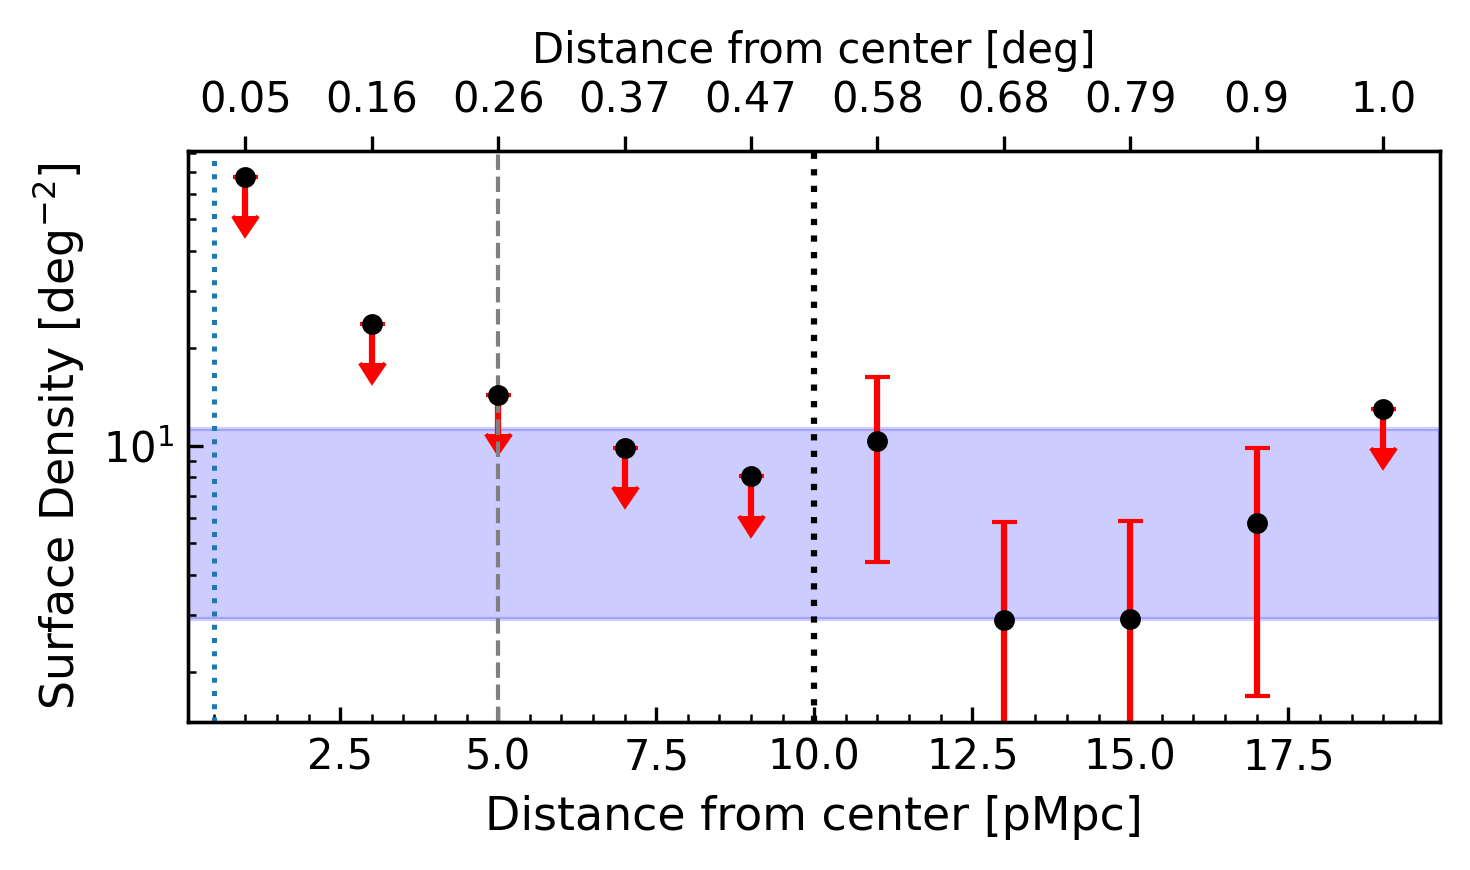

Saved: plots/cdfs_profile.png


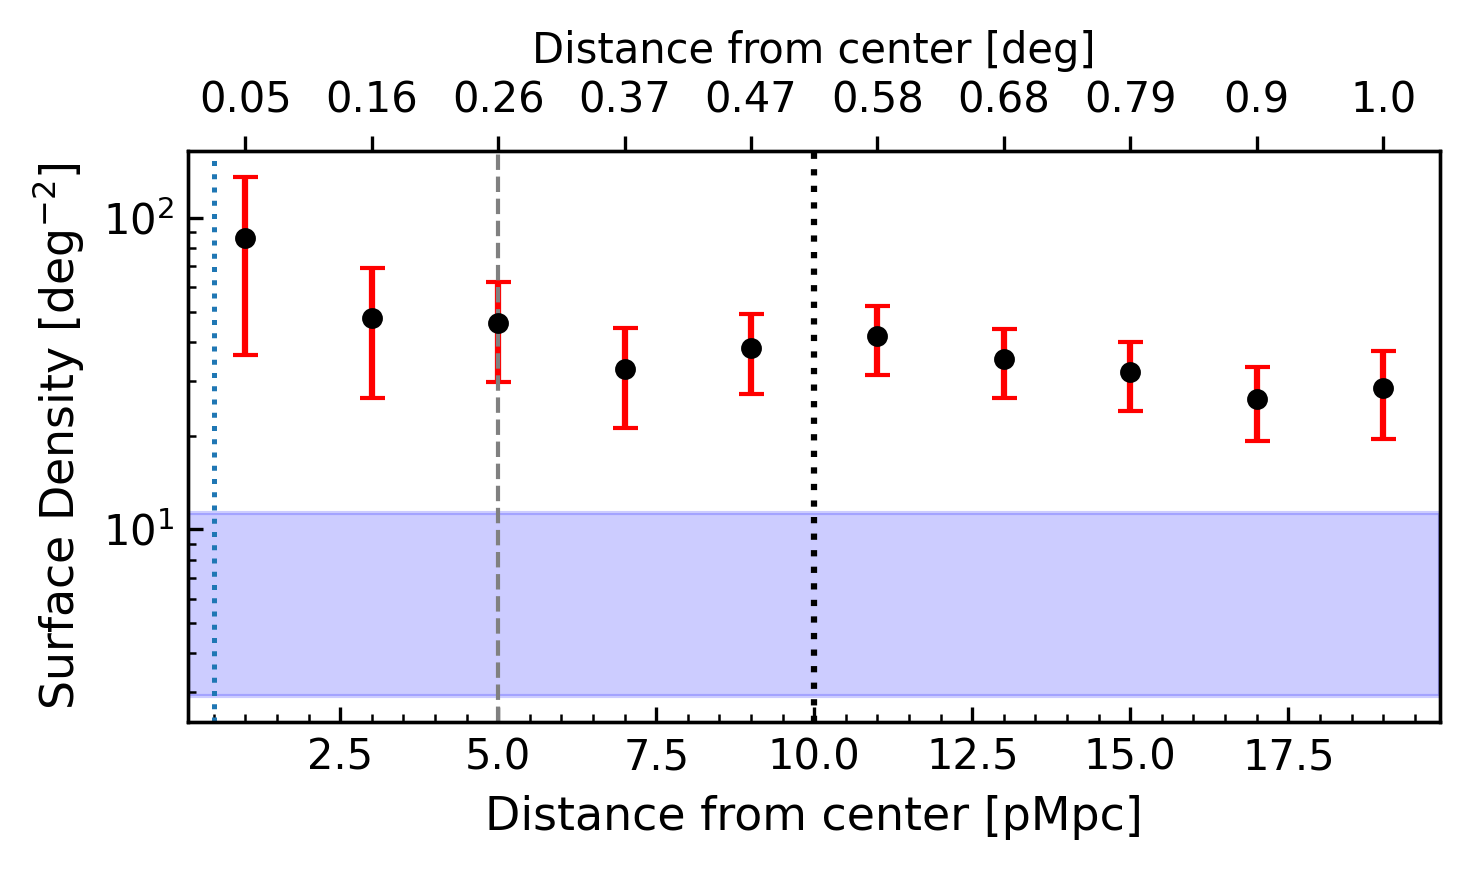

Saved: plots/decam_profile.png


In [16]:
"""
Radial surface density (final corrected + publication-quality)
"""

import numpy as np
from astropy.io import fits
from astropy.wcs import WCS
from astropy.wcs.utils import proj_plane_pixel_scales
import astropy.units as u
from astropy.cosmology import FlatLambdaCDM
from astropy.coordinates import SkyCoord
import matplotlib.pyplot as plt
from scipy.stats import linregress
import os


# ----------------------------
# QSO + COSMOLOGY
# ----------------------------
RA_QSO = 357.138875
DEC_QSO = -30.9028417
REDSHIFT_QSO = 6.9

COSMO = FlatLambdaCDM(H0=70, Om0=0.3)
ARCSEC_PER_KPC = COSMO.arcsec_per_kpc_proper(REDSHIFT_QSO)
ARCSEC_PER_KPC_CO = COSMO.arcsec_per_kpc_comoving(REDSHIFT_QSO)
DEG_PER_MPC = ARCSEC_PER_KPC.to(u.deg / u.Mpc)


# ----------------------------
# MASK CLASS
# ----------------------------
class Mask:
    def __init__(self, file_name: str):
        with fits.open(file_name) as hdu:
            self.data = hdu[0].data
            self.wcs = WCS(hdu[0].header)

        pixel_scales = proj_plane_pixel_scales(self.wcs) * u.deg
        self.deg_per_pix = pixel_scales[0]
        self.pix_area_deg = pixel_scales[0] * pixel_scales[1]

    def calculate_area(self, center, inner_radius, outer_radius):
        y, x = np.indices(self.data.shape)

        dist = np.sqrt((x - center[0])**2 + (y - center[1])**2)
        annulus = (dist >= inner_radius) & (dist <= outer_radius)

        good_pixels = (self.data > 0.5) & annulus

        number_pixels = np.sum(good_pixels)
        return number_pixels * self.pix_area_deg

    @property
    def center(self):
        rows, cols = self.data.shape
        return self.wcs.pixel_to_world_values(cols/2, rows/2)



def calculate_distances(center, file):
    ras, decs = np.loadtxt(file, unpack=True)

    center_coord = SkyCoord(center[0]*u.deg, center[1]*u.deg)
    sources = SkyCoord(ras*u.deg, decs*u.deg)

    return center_coord.separation(sources)



def linear_fit(x, y):
    slope, intercept, _, _, _ = linregress(x, y)
    return slope, intercept



def compute_cdfs_band(counts, areas, radii_mid_mpc):
    areas = np.array([a.value for a in areas])
    counts = counts.astype(float)

    # apply Poisson upper limits
    counts_ul = counts.copy()
    counts_ul[counts == 0] = 1.841

    sigma = counts_ul / areas

    
    outer = radii_mid_mpc > 10

    sigma_outer = sigma[outer]

    low = np.percentile(sigma_outer, 16)
    high = np.percentile(sigma_outer, 84)

    return low, high



def plot_profile(counts, areas, radii_mpc, radii_deg, outfile, band=None):

    areas = np.array([a.value for a in areas])

    valid = areas > 0
    counts = counts[valid]
    areas = areas[valid]
    radii_mpc = radii_mpc[valid]
    radii_deg = radii_deg[valid]

    counts = counts.astype(float)

    zero_idx = np.where(counts == 0)[0]
    nonzero_idx = np.where(counts != 0)[0]

    counts[zero_idx] = 1.841

    y = counts / areas
    yerr = np.sqrt(counts) / areas

    fig, ax = plt.subplots(figsize=(5, 3), dpi=300)

    # detections
    ax.errorbar(
        radii_mpc[nonzero_idx],
        y[nonzero_idx],
        yerr=yerr[nonzero_idx],
        fmt='o',
        color='black',
        ecolor='red',
        capsize=3,
        ms=4
    )

    # upper limits
    ax.errorbar(
        radii_mpc[zero_idx],
        y[zero_idx],
        yerr=yerr[zero_idx]/3,
        fmt='o',
        color='black',
        ecolor='red',
        uplims=True,
        capsize=3,
        ms=4
    )

    # optional fit
    #if len(nonzero_idx) > 2:
       # slope, intercept = linear_fit(radii_mpc[nonzero_idx], y[nonzero_idx])
        #fit_x = np.linspace(min(radii_mpc), max(radii_mpc), 200)
        #ax.plot(fit_x, slope*fit_x + intercept, 'r--', lw=1)

   
    if band is not None:
        ax.axhspan(band[0], band[1], color='blue', alpha=0.2)

    # physical scales
    ax.axvline(5, ls='--', color='gray', lw=1)
    ax.axvline(10, ls=':', color='black', lw=1.5)

    ax.set_yscale('log')
    ax.set_xlabel("Distance from center [pMpc]", fontsize=11)
    ax.set_ylabel("Surface Density [deg$^{-2}$]", fontsize=11)

    ax.tick_params(direction='in', which='both')
    ax.minorticks_on()

    ax2 = ax.twiny()
    ax2.set_xlim(ax.get_xlim())
    ax2.set_xticks(radii_mpc)
    ax2.set_xticklabels(np.round(radii_deg.value, 2))
    ax2.set_xlabel("Distance from center [deg]", fontsize=10)

    max_radius = ARCSEC_PER_KPC_CO * 75 * u.Mpc
    ax.axvline(max_radius.to(u.deg).value, ls=':', lw=1.2)

    plt.tight_layout()
    plt.savefig(outfile, dpi=300)
    plt.show()

    print(f"Saved: {outfile}")


# ----------------------------
# MAIN
# ----------------------------
if __name__ == "__main__":

    CDFS_MASK_FILE = "/Users/aishwarya/Desktop/Mask/cdfs_mask.fits"
    DECAM_MASK_FILE = "/Users/aishwarya/Desktop/Mask/trim2deg_weighted_mask_y.fits"

    CDFS_CATALOG = "/Users/aishwarya/Desktop/source_cdfs_true.txt"
    DECAM_CATALOG = "/Users/aishwarya/Desktop/CSV/Final_sources_ra_dec.txt"

    cdfs = Mask(CDFS_MASK_FILE)
    decam = Mask(DECAM_MASK_FILE)

    cdfs_center_pix = (cdfs.data.shape[1]/2, cdfs.data.shape[0]/2)
    decam_center_pix = decam.wcs.world_to_pixel_values(RA_QSO, DEC_QSO)

    BIN_WIDTH = 2
    radii_mpc = np.arange(0, 20+BIN_WIDTH, BIN_WIDTH) * u.Mpc
    radii_deg = radii_mpc * DEG_PER_MPC

    radii_pix_cdfs = radii_deg / cdfs.deg_per_pix
    radii_pix_decam = radii_deg / decam.deg_per_pix

    radii_mid_mpc = (radii_mpc[:-1] + radii_mpc[1:]) / 2
    radii_mid_deg = radii_mid_mpc * DEG_PER_MPC

    areas_cdfs = [
        cdfs.calculate_area(cdfs_center_pix, radii_pix_cdfs[i], radii_pix_cdfs[i+1])
        for i in range(len(radii_pix_cdfs)-1)
    ]

    areas_decam = [
        decam.calculate_area(decam_center_pix, radii_pix_decam[i], radii_pix_decam[i+1])
        for i in range(len(radii_pix_decam)-1)
    ]

    dist_cdfs = calculate_distances(cdfs.center, CDFS_CATALOG)
    dist_decam = calculate_distances((RA_QSO, DEC_QSO), DECAM_CATALOG)

    dist_decam = dist_decam[dist_decam > 0*u.deg]

    counts_cdfs = np.array([
        np.sum((dist_cdfs >= radii_deg[i]) & (dist_cdfs < radii_deg[i+1]))
        for i in range(len(radii_deg)-1)
    ])

    counts_decam = np.array([
        np.sum((dist_decam >= radii_deg[i]) & (dist_decam < radii_deg[i+1]))
        for i in range(len(radii_deg)-1)
    ])

    
    cdfs_band = compute_cdfs_band(counts_cdfs, areas_cdfs, radii_mid_mpc.value)

    print("CDFS band (low, high):", cdfs_band)

    os.makedirs("plots", exist_ok=True)

    plot_profile(
        counts_cdfs,
        areas_cdfs,
        radii_mid_mpc.value,
        radii_mid_deg,
        "plots/cdfs_profile.png",
        band=cdfs_band
    )

    plot_profile(
        counts_decam,
        areas_decam,
        radii_mid_mpc.value,
        radii_mid_deg,
        "plots/decam_profile.png",
        band=cdfs_band
    )

In [17]:
total_counts = np.sum(counts_cdfs)
total_area = np.sum([a.value for a in areas_cdfs])

sigma_global = total_counts / total_area
print(f"Global surface density: {sigma_global:.2f} deg^-2")

Global surface density: 3.32 deg^-2


Total CDFS counts: 9
Total CDFS area: 2.1103 deg^2
Global density: 4.26 deg^-2
CDFS band (low, high): (np.float64(2.843176273119941), np.float64(5.686352546239882))


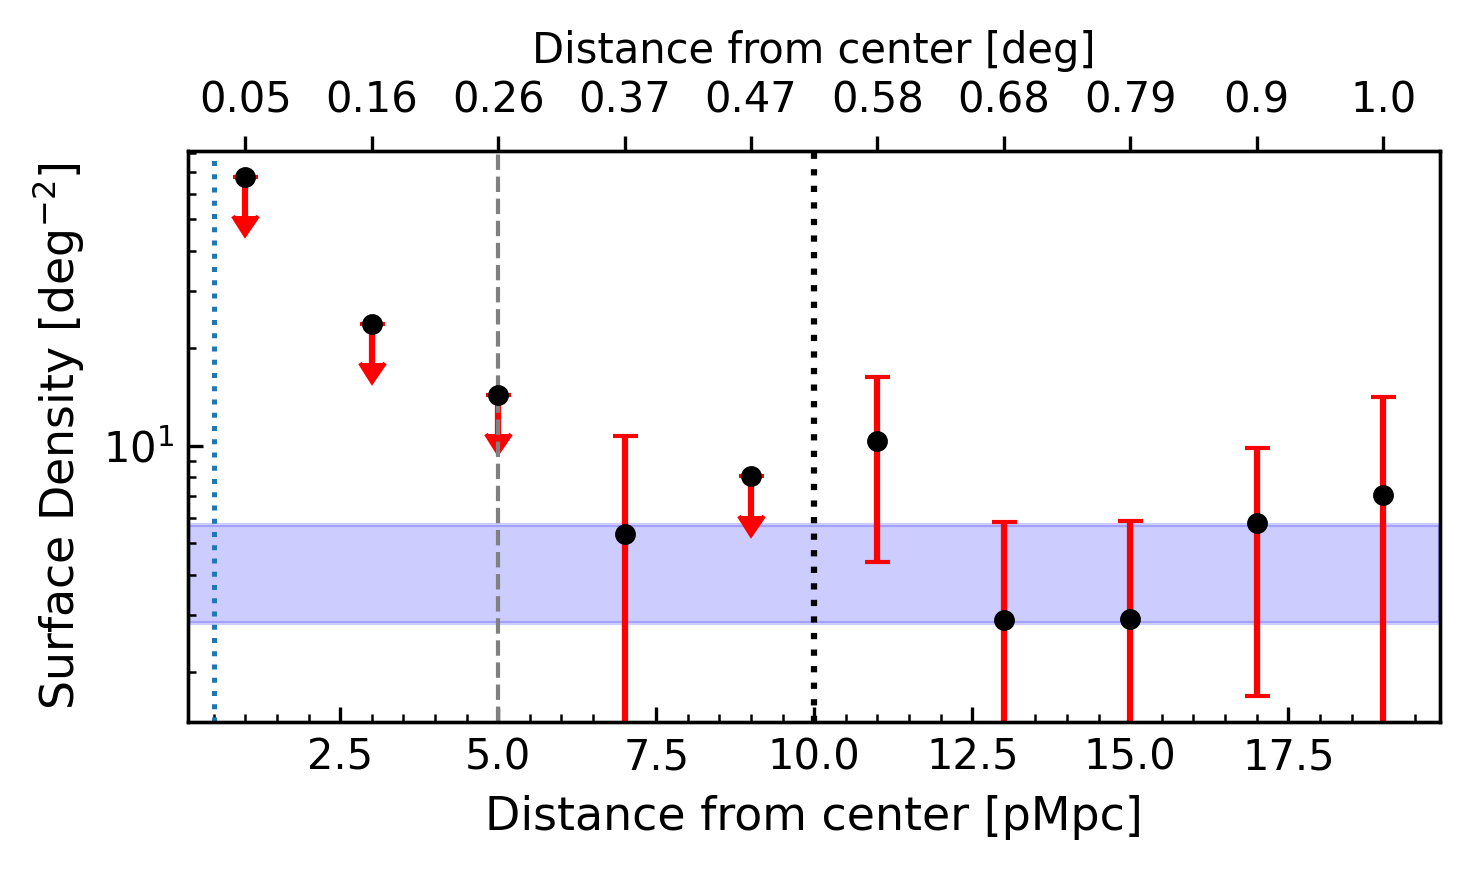

Saved: plots/cdfs_profile.png


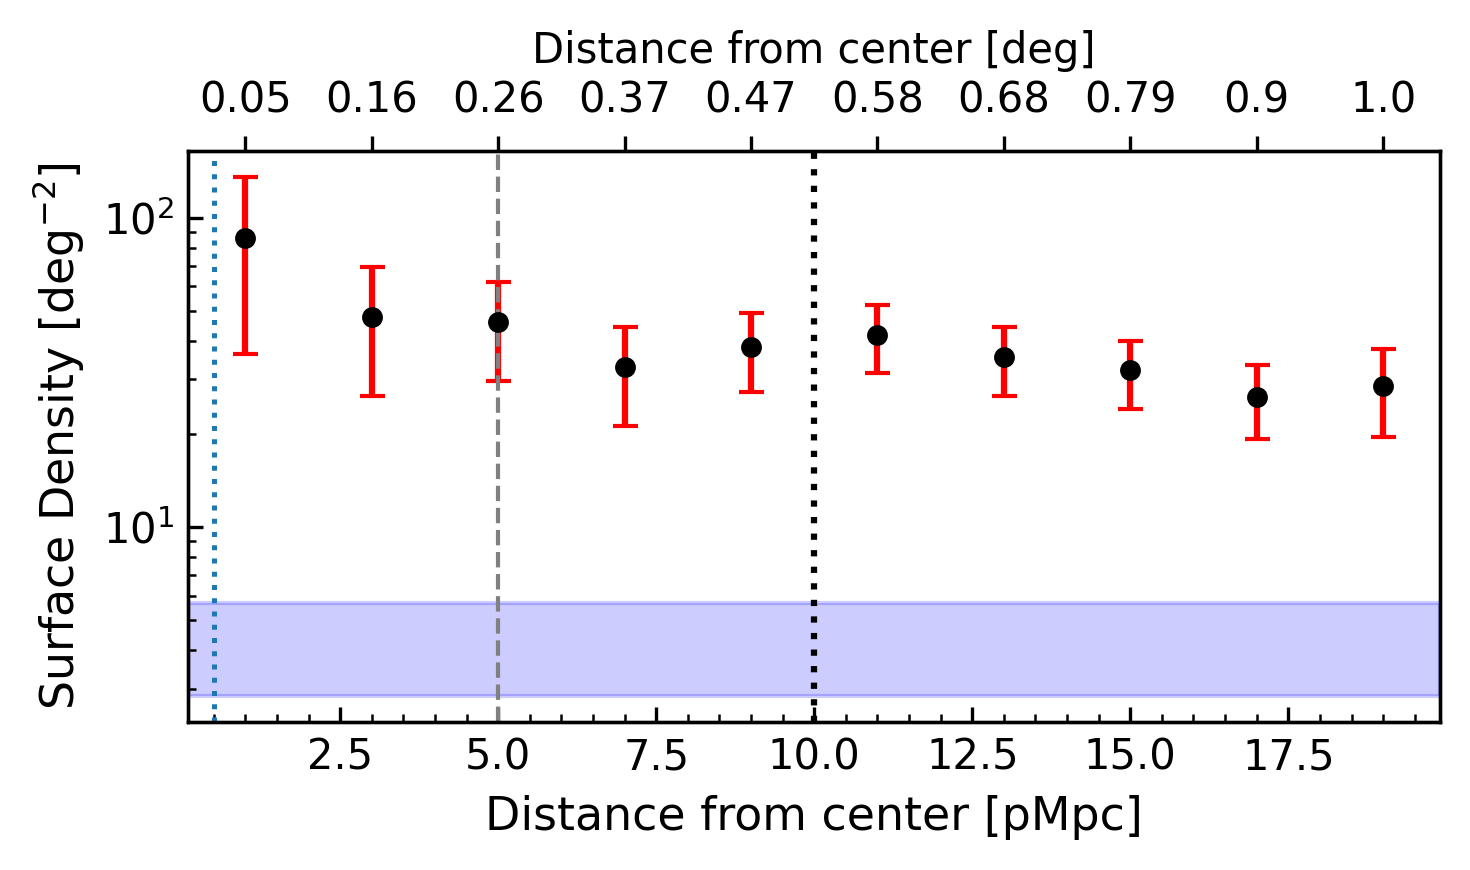

Saved: plots/decam_profile.png


In [27]:
"""
Radial surface density (final corrected + publication-quality)
"""

import numpy as np
from astropy.io import fits
from astropy.wcs import WCS
from astropy.wcs.utils import proj_plane_pixel_scales
import astropy.units as u
from astropy.cosmology import FlatLambdaCDM
from astropy.coordinates import SkyCoord
import matplotlib.pyplot as plt
from scipy.stats import linregress
import os


# ----------------------------
# QSO + COSMOLOGY
# ----------------------------
RA_QSO = 357.138875
DEC_QSO = -30.9028417
REDSHIFT_QSO = 6.9

COSMO = FlatLambdaCDM(H0=70, Om0=0.3)
ARCSEC_PER_KPC = COSMO.arcsec_per_kpc_proper(REDSHIFT_QSO)
ARCSEC_PER_KPC_CO = COSMO.arcsec_per_kpc_comoving(REDSHIFT_QSO)
DEG_PER_MPC = ARCSEC_PER_KPC.to(u.deg / u.Mpc)


# ----------------------------
# MASK CLASS
# ----------------------------
class Mask:
    def __init__(self, file_name: str):
        with fits.open(file_name) as hdu:
            self.data = hdu[0].data
            self.wcs = WCS(hdu[0].header)

        pixel_scales = proj_plane_pixel_scales(self.wcs) * u.deg
        self.deg_per_pix = pixel_scales[0]
        self.pix_area_deg = pixel_scales[0] * pixel_scales[1]

    def calculate_area(self, center, inner_radius, outer_radius):
        y, x = np.indices(self.data.shape)

        dist = np.sqrt((x - center[0])**2 + (y - center[1])**2)
        annulus = (dist >= inner_radius) & (dist <= outer_radius)

        good_pixels = (self.data > 0.5) & annulus

        number_pixels = np.sum(good_pixels)
        return number_pixels * self.pix_area_deg

    @property
    def center(self):
        rows, cols = self.data.shape
        return self.wcs.pixel_to_world_values(cols/2, rows/2)



def calculate_distances(center, file):
    ras, decs = np.loadtxt(file, unpack=True)

    center_coord = SkyCoord(center[0]*u.deg, center[1]*u.deg)
    sources = SkyCoord(ras*u.deg, decs*u.deg)

    return center_coord.separation(sources)



def linear_fit(x, y):
    slope, intercept, _, _, _ = linregress(x, y)
    return slope, intercept



def compute_cdfs_band(counts, areas):
    """
    Compute global surface density band using Poisson statistics
    """

    areas = np.array([a.value for a in areas])
    total_area = np.sum(areas)
    total_counts = np.sum(counts)

    print(f"Total CDFS counts: {total_counts}")
    print(f"Total CDFS area: {total_area:.4f} deg^2")

    # Global surface density
    rho = total_counts / total_area

    # Poisson errors (Gehrels 1986 approximation)
    err_low = rho - (total_counts - np.sqrt(total_counts)) / total_area
    err_high = ((total_counts + np.sqrt(total_counts)) / total_area) - rho

    low = rho - err_low
    high = rho + err_high

    print(f"Global density: {rho:.2f} deg^-2")

    return low, high


def plot_profile(counts, areas, radii_mpc, radii_deg, outfile, band=None):

    areas = np.array([a.value for a in areas])

    valid = areas > 0
    counts = counts[valid]
    areas = areas[valid]
    radii_mpc = radii_mpc[valid]
    radii_deg = radii_deg[valid]

    counts = counts.astype(float)

    zero_idx = np.where(counts == 0)[0]
    nonzero_idx = np.where(counts != 0)[0]

    counts[zero_idx] = 1.841

    y = counts / areas
    yerr = np.sqrt(counts) / areas

    fig, ax = plt.subplots(figsize=(5, 3), dpi=300)

    # detections
    ax.errorbar(
        radii_mpc[nonzero_idx],
        y[nonzero_idx],
        yerr=yerr[nonzero_idx],
        fmt='o',
        color='black',
        ecolor='red',
        capsize=3,
        ms=4
    )

    # upper limits
    ax.errorbar(
        radii_mpc[zero_idx],
        y[zero_idx],
        yerr=yerr[zero_idx]/3,
        fmt='o',
        color='black',
        ecolor='red',
        uplims=True,
        capsize=3,
        ms=4
    )

    # optional fit
    #if len(nonzero_idx) > 2:
       # slope, intercept = linear_fit(radii_mpc[nonzero_idx], y[nonzero_idx])
        #fit_x = np.linspace(min(radii_mpc), max(radii_mpc), 200)
        #ax.plot(fit_x, slope*fit_x + intercept, 'r--', lw=1)

   
    if band is not None:
        ax.axhspan(band[0], band[1], color='blue', alpha=0.2)

    # physical scales
    ax.axvline(5, ls='--', color='gray', lw=1)
    ax.axvline(10, ls=':', color='black', lw=1.5)

    ax.set_yscale('log')
    ax.set_xlabel("Distance from center [pMpc]", fontsize=11)
    ax.set_ylabel("Surface Density [deg$^{-2}$]", fontsize=11)

    ax.tick_params(direction='in', which='both')
    ax.minorticks_on()

    ax2 = ax.twiny()
    ax2.set_xlim(ax.get_xlim())
    ax2.set_xticks(radii_mpc)
    ax2.set_xticklabels(np.round(radii_deg.value, 2))
    ax2.set_xlabel("Distance from center [deg]", fontsize=10)

    max_radius = ARCSEC_PER_KPC_CO * 75 * u.Mpc
    ax.axvline(max_radius.to(u.deg).value, ls=':', lw=1.2)

    plt.tight_layout()
    plt.savefig(outfile, dpi=300)
    plt.show()

    print(f"Saved: {outfile}")


# ----------------------------
# MAIN
# ----------------------------
if __name__ == "__main__":

    CDFS_MASK_FILE = "/Users/aishwarya/Desktop/Mask/cdfs_mask.fits"
    DECAM_MASK_FILE = "/Users/aishwarya/Desktop/Mask/trim2deg_weighted_mask_y.fits"

    CDFS_CATALOG = "/Users/aishwarya/Desktop/source_cdfs_true.txt"
    DECAM_CATALOG = "/Users/aishwarya/Desktop/CSV/Final_sources_ra_dec.txt"

    cdfs = Mask(CDFS_MASK_FILE)
    decam = Mask(DECAM_MASK_FILE)

    cdfs_center_pix = (cdfs.data.shape[1]/2, cdfs.data.shape[0]/2)
    decam_center_pix = decam.wcs.world_to_pixel_values(RA_QSO, DEC_QSO)

    BIN_WIDTH = 2
    radii_mpc = np.arange(0, 20+BIN_WIDTH, BIN_WIDTH) * u.Mpc
    radii_deg = radii_mpc * DEG_PER_MPC

    radii_pix_cdfs = radii_deg / cdfs.deg_per_pix
    radii_pix_decam = radii_deg / decam.deg_per_pix

    radii_mid_mpc = (radii_mpc[:-1] + radii_mpc[1:]) / 2
    radii_mid_deg = radii_mid_mpc * DEG_PER_MPC

    areas_cdfs = [
        cdfs.calculate_area(cdfs_center_pix, radii_pix_cdfs[i], radii_pix_cdfs[i+1])
        for i in range(len(radii_pix_cdfs)-1)
    ]

    areas_decam = [
        decam.calculate_area(decam_center_pix, radii_pix_decam[i], radii_pix_decam[i+1])
        for i in range(len(radii_pix_decam)-1)
    ]

    dist_cdfs = calculate_distances(cdfs.center, CDFS_CATALOG)
    dist_decam = calculate_distances((RA_QSO, DEC_QSO), DECAM_CATALOG)

    dist_decam = dist_decam[dist_decam > 0*u.deg]

    counts_cdfs = np.array([
        np.sum((dist_cdfs >= radii_deg[i]) & (dist_cdfs < radii_deg[i+1]))
        for i in range(len(radii_deg)-1)
    ])

    counts_decam = np.array([
        np.sum((dist_decam >= radii_deg[i]) & (dist_decam < radii_deg[i+1]))
        for i in range(len(radii_deg)-1)
    ])

    
    cdfs_band = compute_cdfs_band(counts_cdfs, areas_cdfs)
    print("CDFS band (low, high):", cdfs_band)

    os.makedirs("plots", exist_ok=True)

    plot_profile(
        counts_cdfs,
        areas_cdfs,
        radii_mid_mpc.value,
        radii_mid_deg,
        "plots/cdfs_profile.png",
        band=cdfs_band
    )

    plot_profile(
        counts_decam,
        areas_decam,
        radii_mid_mpc.value,
        radii_mid_deg,
        "plots/decam_profile.png",
        band=cdfs_band
    )

In [23]:
input_file  = "/Users/aishwarya/Desktop/CSV/Final_sources_ra_dec.txt"
output_file = "/Users/aishwarya/Desktop/CSV/Final_sources_ra_dec.reg"

with open(input_file, "r") as f:
    lines = f.readlines()

with open(output_file, "w") as f:
    # DS9 header
    f.write("# Region file format: DS9 version 4.1\n")
    f.write("global color=green width=1\n")
    f.write("fk5\n")

    for line in lines:
        if line.strip() == "":
            continue
        
        ra, dec = map(float, line.split())

        # Point marker
        f.write(f"point({ra},{dec}) # point=cross\n")

        # Circle (2 arcsec radius)
        f.write(f"circle({ra},{dec},2\")\n")

print("Region file created:", output_file)

Region file created: /Users/aishwarya/Desktop/CSV/Final_sources_ra_dec.reg


# Overdensity

In [28]:
def plot_overdensity(counts, areas, radii_mpc, outfile, cdfs_band):

    areas = np.array([a.value for a in areas])
    valid = areas > 0

    counts = counts[valid].astype(float)
    areas = areas[valid]
    radii_mpc = radii_mpc[valid]

    zero_idx = np.where(counts == 0)[0]
    nonzero_idx = np.where(counts != 0)[0]

    counts[zero_idx] = 1.841

    sigma = counts / areas
    sigma_err = np.sqrt(counts) / areas

    # CDFS global density
    rho_cdfs = np.mean(cdfs_band)

    delta = (sigma - rho_cdfs) / rho_cdfs
    delta_err = sigma_err / rho_cdfs

    fig, ax = plt.subplots(figsize=(5,3), dpi=300)

    # detections
    ax.errorbar(
        radii_mpc[nonzero_idx],
        delta[nonzero_idx],
        yerr=delta_err[nonzero_idx],
        fmt='o',
        color='black',
        ecolor='red',
        capsize=3,
        ms=4
    )

    # upper limits
    ax.errorbar(
        radii_mpc[zero_idx],
        delta[zero_idx],
        yerr=delta_err[zero_idx]/3,
        fmt='o',
        color='black',
        ecolor='red',
        uplims=True,
        capsize=3,
        ms=4
    )

    # field level
    ax.axhline(0, color='blue', ls='--', lw=1)

    ax.axvline(5, ls='--', color='gray', lw=1)
    ax.axvline(10, ls=':', color='black', lw=1.5)

    ax.set_xlabel("Distance from center [pMpc]", fontsize=11)
    ax.set_ylabel("Overdensity ", fontsize=11)

    ax.tick_params(direction='in', which='both')
    ax.minorticks_on()

    plt.tight_layout()
    plt.savefig(outfile, dpi=300)
    plt.show()

    print(f"Saved: {outfile}")

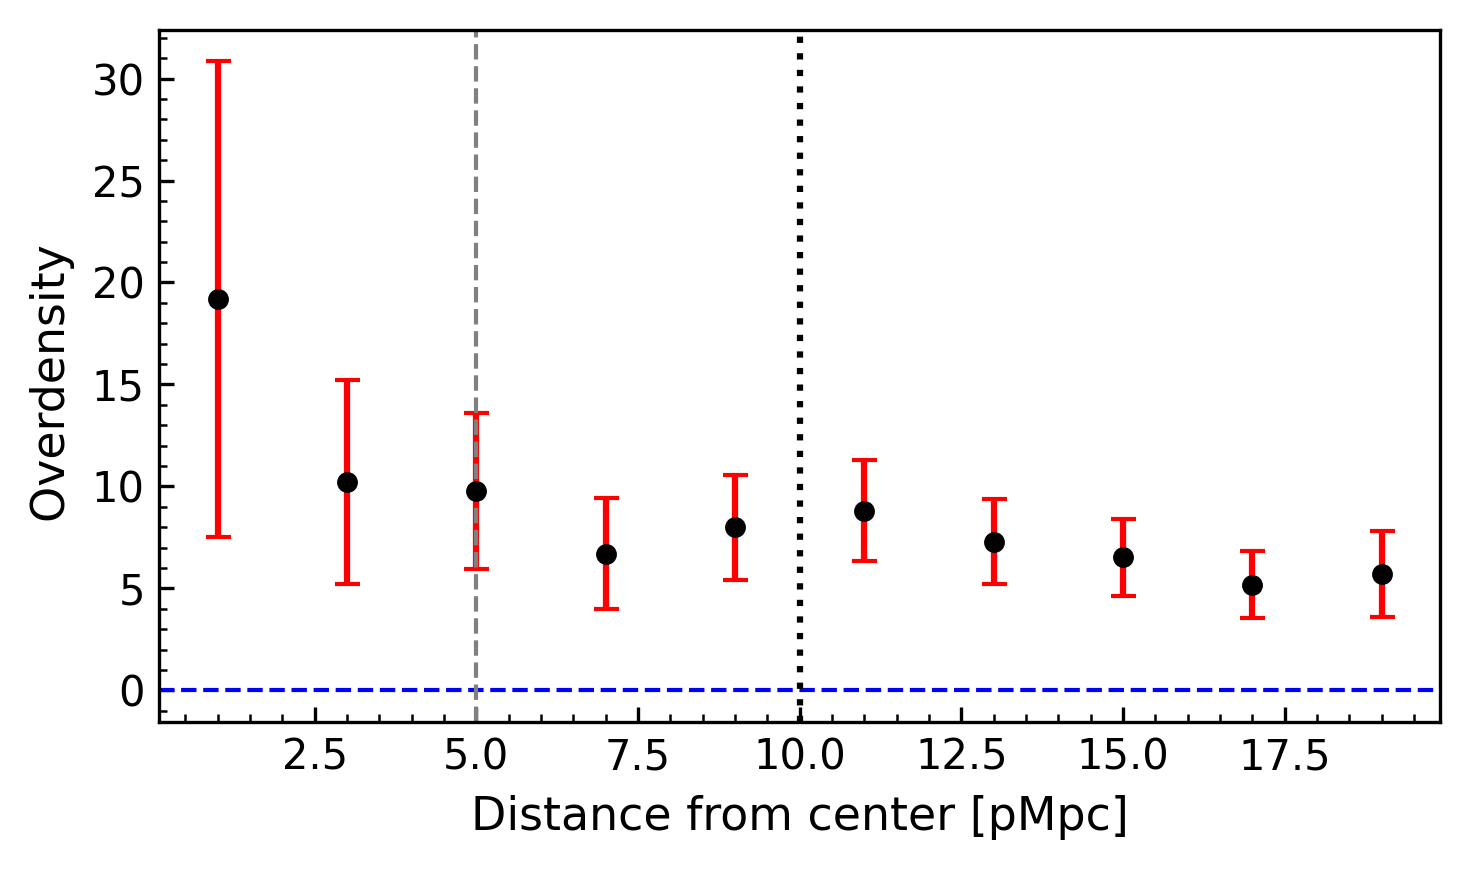

Saved: plots/decam_overdensity.png


In [29]:
plot_overdensity(
    counts_decam,
    areas_decam,
    radii_mid_mpc.value,
    "plots/decam_overdensity.png",
    cdfs_band
)

CDFS counts per bin: [0 0 0 1 0 3 1 1 2 1]
DECAM counts per bin: [ 3  5  8  8 12 16 16 16 14 10]
CDFS mean surface density: 4.26 ± 1.42 deg^-2
DECam mean surface density: 35.00 ± 3.37 deg^-2
Overdensity values: [15.87630313  5.58441617  3.37584753  1.25612068  1.8913727   2.42495388
  0.68194094  0.68679583  1.35419415  1.65812559]


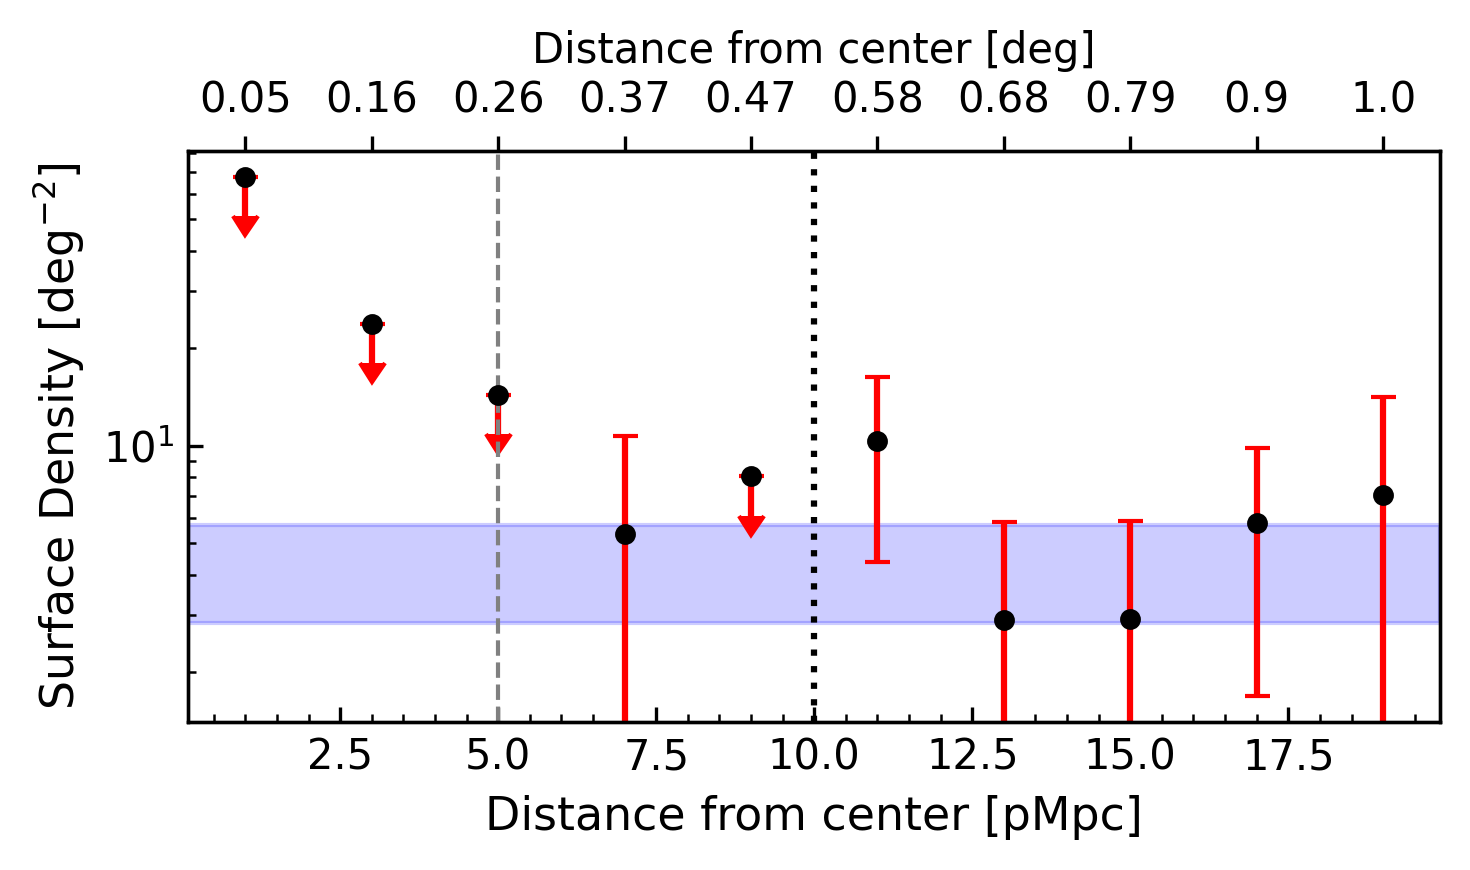

Saved: plots/cdfs_profile.png
Overdensity values: [20.18610963 11.22064593 10.77488644  7.70308455  8.98508927  9.81755203
  8.29058389  7.52234773  6.17441585  6.68819911]


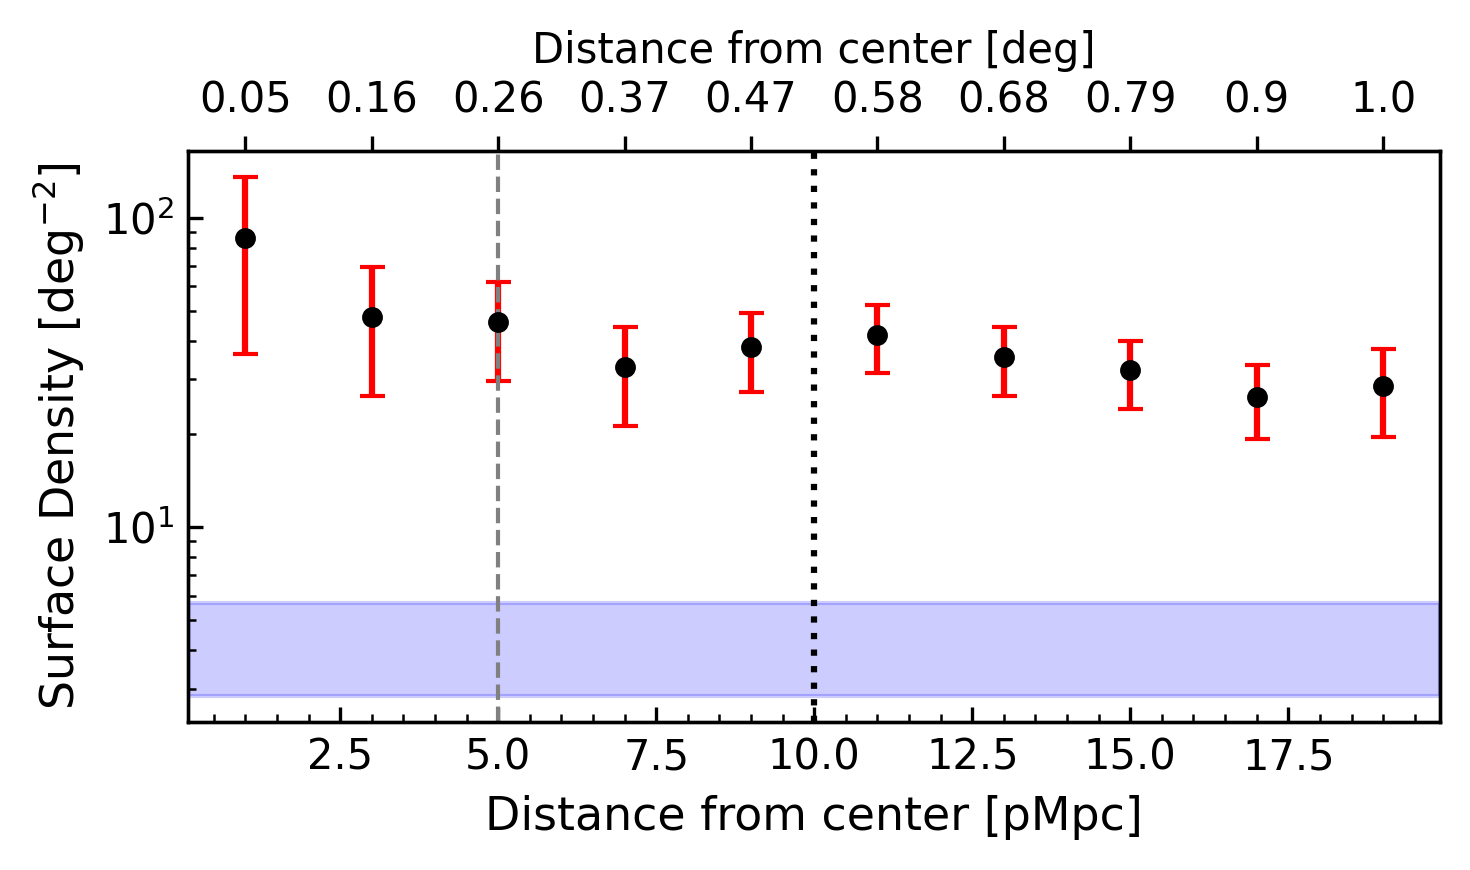

Saved: plots/decam_profile.png


In [30]:
"""
Radial surface density (final corrected + publication-quality)
"""

import numpy as np
from astropy.io import fits
from astropy.wcs import WCS
from astropy.wcs.utils import proj_plane_pixel_scales
import astropy.units as u
from astropy.cosmology import FlatLambdaCDM
from astropy.coordinates import SkyCoord
import matplotlib.pyplot as plt
from scipy.stats import linregress
import os


# ----------------------------
# QSO + COSMOLOGY
# ----------------------------
RA_QSO = 357.138875
DEC_QSO = -30.9028417
REDSHIFT_QSO = 6.9

COSMO = FlatLambdaCDM(H0=70, Om0=0.3)
ARCSEC_PER_KPC = COSMO.arcsec_per_kpc_proper(REDSHIFT_QSO)
DEG_PER_MPC = ARCSEC_PER_KPC.to(u.deg / u.Mpc)


# ----------------------------
# MASK CLASS
# ----------------------------
class Mask:
    def __init__(self, file_name: str):
        with fits.open(file_name) as hdu:
            self.data = hdu[0].data
            self.wcs = WCS(hdu[0].header)

        pixel_scales = proj_plane_pixel_scales(self.wcs) * u.deg
        self.deg_per_pix = pixel_scales[0]
        self.pix_area_deg = pixel_scales[0] * pixel_scales[1]

    def calculate_area(self, center, inner_radius, outer_radius):
        y, x = np.indices(self.data.shape)

        dist = np.sqrt((x - center[0])**2 + (y - center[1])**2)
        annulus = (dist >= inner_radius) & (dist <= outer_radius)

        good_pixels = (self.data > 0.5) & annulus
        number_pixels = np.sum(good_pixels)

        return number_pixels * self.pix_area_deg

    @property
    def center(self):
        rows, cols = self.data.shape
        return self.wcs.pixel_to_world_values(cols/2, rows/2)


# ----------------------------
# DISTANCES
# ----------------------------
def calculate_distances(center, file):
    ras, decs = np.loadtxt(file, unpack=True)

    center_coord = SkyCoord(center[0]*u.deg, center[1]*u.deg)
    sources = SkyCoord(ras*u.deg, decs*u.deg)

    return center_coord.separation(sources)


# ----------------------------
# SURFACE DENSITY
# ----------------------------
def compute_surface_density(counts, areas, label="Field"):
    areas = np.array([a.value for a in areas])
    total_area = np.sum(areas)
    total_counts = np.sum(counts)

    rho = total_counts / total_area
    rho_err = np.sqrt(total_counts) / total_area

    print(f"{label} mean surface density: {rho:.2f} ± {rho_err:.2f} deg^-2")

    return rho, rho_err


def compute_band(rho, rho_err):
    return rho - rho_err, rho + rho_err


# ----------------------------
# PLOTTING
# ----------------------------
def plot_profile(counts, areas, radii_mpc, radii_deg, outfile, rho_field, band=None):

    areas = np.array([a.value for a in areas])

    valid = areas > 0
    counts = counts[valid]
    areas = areas[valid]
    radii_mpc = radii_mpc[valid]
    radii_deg = radii_deg[valid]

    counts = counts.astype(float)

    zero_idx = np.where(counts == 0)[0]
    nonzero_idx = np.where(counts != 0)[0]

    counts[zero_idx] = 1.841  # Gehrels approx

    y = counts / areas
    yerr = np.sqrt(counts) / areas

    overdensity = y / rho_field
    print("Overdensity values:", overdensity)

    fig, ax = plt.subplots(figsize=(5, 3), dpi=300)

    # detections
    ax.errorbar(
        radii_mpc[nonzero_idx],
        y[nonzero_idx],
        yerr=yerr[nonzero_idx],
        fmt='o',
        color='black',
        ecolor='red',
        capsize=3,
        ms=4
    )

    # upper limits
    ax.errorbar(
        radii_mpc[zero_idx],
        y[zero_idx],
        yerr=yerr[zero_idx]/3,
        fmt='o',
        color='black',
        ecolor='red',
        uplims=True,
        capsize=3,
        ms=4
    )

    if band is not None:
        ax.axhspan(band[0], band[1], color='blue', alpha=0.2)

    ax.axvline(5, ls='--', color='gray', lw=1)
    ax.axvline(10, ls=':', color='black', lw=1.5)

    ax.set_yscale('log')
    ax.set_xlabel("Distance from center [pMpc]", fontsize=11)
    ax.set_ylabel("Surface Density [deg$^{-2}$]", fontsize=11)

    ax.tick_params(direction='in', which='both')
    ax.minorticks_on()

    ax2 = ax.twiny()
    ax2.set_xlim(ax.get_xlim())
    ax2.set_xticks(radii_mpc)
    ax2.set_xticklabels(np.round(radii_deg.value, 2))
    ax2.set_xlabel("Distance from center [deg]", fontsize=10)

    plt.tight_layout()
    plt.savefig(outfile, dpi=300)
    plt.show()

    print(f"Saved: {outfile}")


# ----------------------------
# MAIN
# ----------------------------
if __name__ == "__main__":

    CDFS_MASK_FILE = "/Users/aishwarya/Desktop/Mask/cdfs_mask.fits"
    DECAM_MASK_FILE = "/Users/aishwarya/Desktop/Mask/trim2deg_weighted_mask_y.fits"

    CDFS_CATALOG = "/Users/aishwarya/Desktop/source_cdfs_true.txt"
    DECAM_CATALOG = "/Users/aishwarya/Desktop/CSV/Final_sources_ra_dec.txt"

    cdfs = Mask(CDFS_MASK_FILE)
    decam = Mask(DECAM_MASK_FILE)

    cdfs_center_pix = (cdfs.data.shape[1]/2, cdfs.data.shape[0]/2)
    decam_center_pix = decam.wcs.world_to_pixel_values(RA_QSO, DEC_QSO)

    BIN_WIDTH = 2
    radii_mpc = np.arange(0, 20+BIN_WIDTH, BIN_WIDTH) * u.Mpc
    radii_deg = radii_mpc * DEG_PER_MPC

    radii_pix_cdfs = radii_deg / cdfs.deg_per_pix
    radii_pix_decam = radii_deg / decam.deg_per_pix

    radii_mid_mpc = (radii_mpc[:-1] + radii_mpc[1:]) / 2
    radii_mid_deg = radii_mid_mpc * DEG_PER_MPC

    areas_cdfs = [
        cdfs.calculate_area(cdfs_center_pix, radii_pix_cdfs[i], radii_pix_cdfs[i+1])
        for i in range(len(radii_pix_cdfs)-1)
    ]

    areas_decam = [
        decam.calculate_area(decam_center_pix, radii_pix_decam[i], radii_pix_decam[i+1])
        for i in range(len(radii_pix_decam)-1)
    ]

    dist_cdfs = calculate_distances(cdfs.center, CDFS_CATALOG)
    dist_decam = calculate_distances((RA_QSO, DEC_QSO), DECAM_CATALOG)

    dist_decam = dist_decam[dist_decam > 0*u.deg]

    counts_cdfs = np.array([
        np.sum((dist_cdfs >= radii_deg[i]) & (dist_cdfs < radii_deg[i+1]))
        for i in range(len(radii_deg)-1)
    ])

    counts_decam = np.array([
        np.sum((dist_decam >= radii_deg[i]) & (dist_decam < radii_deg[i+1]))
        for i in range(len(radii_deg)-1)
    ])

    print("CDFS counts per bin:", counts_cdfs)
    print("DECAM counts per bin:", counts_decam)

    # ----------------------------
    # GLOBAL SURFACE DENSITIES
    # ----------------------------
    rho_cdfs, err_cdfs = compute_surface_density(counts_cdfs, areas_cdfs, "CDFS")
    rho_decam, err_decam = compute_surface_density(counts_decam, areas_decam, "DECam")

    cdfs_band = compute_band(rho_cdfs, err_cdfs)

    os.makedirs("plots", exist_ok=True)

    # ----------------------------
    # PLOTS
    # ----------------------------
    plot_profile(
        counts_cdfs,
        areas_cdfs,
        radii_mid_mpc.value,
        radii_mid_deg,
        "plots/cdfs_profile.png",
        rho_cdfs,
        band=cdfs_band
    )

    plot_profile(
        counts_decam,
        areas_decam,
        radii_mid_mpc.value,
        radii_mid_deg,
        "plots/decam_profile.png",
        rho_cdfs,  # IMPORTANT: compare to field
        band=cdfs_band
    )